In [1]:
!pip install tensorflow pandas scikit-learn openpyxl matplotlib seaborn

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
ZIP_PATH = "NFLD_UltraSound_Image_&_Clinical_Dataset.zip"
EXTRACT_DIR = "./dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

LABEL_MAP = {"normal": 0, "benign": 1, "malignant": 2}
CLASS_NAMES = ["Normal", "Benign", "Malignant"]

In [5]:
from google.colab import files
uploaded = files.upload()

Saving NFLD_UltraSound_Image_&_Clinical_Dataset (1).zip to NFLD_UltraSound_Image_&_Clinical_Dataset (1).zip


In [6]:
print(os.listdir())

['.config', 'NFLD_UltraSound_Image_&_Clinical_Dataset (1).zip', 'dataset', 'sample_data']


In [7]:
ZIP_PATH = "NFLD_UltraSound_Image_&_Clinical_Dataset (1).zip"
EXTRACT_DIR = "./dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 30

LABEL_MAP = {"normal": 0, "benign": 1, "malignant": 2}
CLASS_NAMES = ["Normal", "Benign", "Malignant"]

In [8]:
def extract_dataset(zip_path, extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)

    root = Path(extract_dir)
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    return subdirs[0] if subdirs else root

dataset_root = extract_dataset(ZIP_PATH, EXTRACT_DIR)

excel_files = list(dataset_root.glob("*.xlsx"))
EXCEL_PATH = excel_files[0]

IMAGES_ROOT = dataset_root / "images"

print("Dataset extracted")

Dataset extracted


In [9]:
df = pd.read_excel(EXCEL_PATH)
df.columns = df.columns.str.strip()

id_col = [c for c in df.columns if c.upper() == "ID"][0]
label_col = [c for c in df.columns if "grade" in c.lower() or "label" in c.lower()][0]

df = df.dropna(subset=[label_col])
df[id_col] = df[id_col].str.lower()

print(df.head())

    ID  Age  Gender(Female=1,Male=2)    BMI  Waist_cm  ALT  AST  Glucose  \
0  id1   32                        2  26.09       NaN   31   23    119.0   
1  id2   43                        2  27.40     101.0   26   24    106.0   
2  id3   55                        2  27.92      99.0   19   20    141.0   
3  id4   33                        2  31.02     114.0   72   31     90.0   
4  id5   23                        2  25.91     101.0   51   32     89.0   

   Cholesterol    LDL  HDL  Triglycerides  \
0          141   87.0   40             72   
1          228  161.0   59            128   
2          183   76.0   28            396   
3          199  102.0   36            304   
4          211  144.0   34            164   

   Liver Grade( Normal=0, Benign=1, Malignant=2)  
0                                              0  
1                                              0  
2                                              0  
3                                              2  
4                

In [10]:
def build_image_index(images_root):
    index = {}
    for class_name, class_int in LABEL_MAP.items():
        folder = images_root / class_name
        for img_file in folder.glob("*.jpg"):
            index[img_file.stem.lower()] = (str(img_file), class_int)
    return index

image_index = build_image_index(IMAGES_ROOT)

matched_ids = [pid for pid in df[id_col] if pid in image_index]
df_matched = df[df[id_col].isin(matched_ids)]

print("Matched:", len(df_matched))

Matched: 86


In [11]:
exclude_cols = [id_col, label_col]

feature_cols = [c for c in df_matched.columns
                if c not in exclude_cols
                and pd.api.types.is_numeric_dtype(df_matched[c])]

for col in feature_cols:
    df_matched[col] = df_matched[col].fillna(df_matched[col].median())

X_clinical = df_matched[feature_cols].values.astype(np.float32)
y_labels = df_matched[label_col].values.astype(np.int32)
patient_ids = df_matched[id_col].values

print("Features ready")

Features ready


/tmp/ipykernel_18882/4061840659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched[col] = df_matched[col].fillna(df_matched[col].median())


In [12]:
def load_image(pid):
    path, _ = image_index[pid]
    img = load_img(path, target_size=IMG_SIZE)
    return img_to_array(img)/255.0

X_images = np.array([load_image(pid) for pid in patient_ids])
print("Images loaded:", X_images.shape)

Images loaded: (86, 224, 224, 3)


In [13]:
idx = np.arange(len(y_labels))

train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y_labels)

X_img_train = X_images[train_idx]
X_img_test  = X_images[test_idx]

X_clin_train = X_clinical[train_idx]
X_clin_test  = X_clinical[test_idx]

scaler = StandardScaler()
X_clin_train = scaler.fit_transform(X_clin_train)
X_clin_test  = scaler.transform(X_clin_test)

y_train = tf.keras.utils.to_categorical(y_labels[train_idx], 3)
y_test  = tf.keras.utils.to_categorical(y_labels[test_idx], 3)

print("Split done")

Split done


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices(
    ({"image_input": X_img_train, "clinical_input": X_clin_train}, y_train)
).batch(BATCH_SIZE)

test_ds = tf.data.Dataset.from_tensor_slices(
    ({"image_input": X_img_test, "clinical_input": X_clin_test}, y_test)
).batch(BATCH_SIZE)

In [15]:
image_input = Input(shape=(224,224,3), name="image_input")
base = MobileNetV2(include_top=False, weights="imagenet")
base.trainable = False

x_img = base(image_input)
x_img = layers.GlobalAveragePooling2D()(x_img)

clinical_input = Input(shape=(X_clin_train.shape[1],), name="clinical_input")
x_clin = layers.Dense(32, activation="relu")(clinical_input)

fusion = layers.Concatenate()([x_img, x_clin])
x = layers.Dense(64, activation="relu")(fusion)

output = layers.Dense(3, activation="softmax")(x)

model = Model([image_input, clinical_input], output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_18882/1019484783.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        384 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     84,032 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,342,595 (8.94 MB)

 Trainable params: 84,611 (330.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(train_ds, epochs=EPOCHS)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.4853 - loss: 1.1562
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.6765 - loss: 0.6476
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.7647 - loss: 0.4582
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy: 0.8676 - loss: 0.3247
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.9412 - loss: 0.2526
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.9559 - loss: 0.1969
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 1.0000 - loss: 0.1499
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 1.0000 - loss: 0.1212
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 1.0000 - loss: 0.0972
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 1.0000 - loss: 0.0803
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 1.0000 - loss: 0.0678
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 1.0000 - lo

In [17]:
y_pred = np.argmax(model.predict(test_ds), axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Accuracy: 0.4444444444444444
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.50      0.50        10
           2       0.38      0.50      0.43         6

    accuracy                           0.44        18
   macro avg       0.29      0.33      0.31        18
weighted avg       0.40      0.44      0.42        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


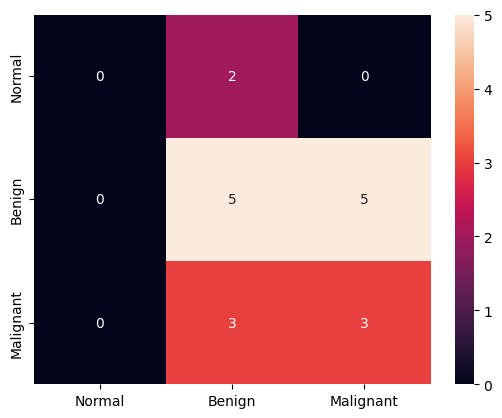

In [18]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.show()

In [19]:
# 🔹 Load single image
def predict_patient(image_path, clinical_data):

    # Load and preprocess image
    img = load_img(image_path, target_size=(224,224))
    img = img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    # Preprocess clinical data (VERY IMPORTANT: use same scaler)
    clinical_data = np.array(clinical_data).reshape(1, -1)
    clinical_data = scaler.transform(clinical_data)

    # Predict
    pred = model.predict({
        "image_input": img,
        "clinical_input": clinical_data
    })

    class_idx = np.argmax(pred)
    class_name = CLASS_NAMES[class_idx]

    print("Prediction:", class_name)
    print("Confidence:", np.max(pred))

    return class_name

In [23]:
print(feature_cols)

['Age', 'Gender(Female=1,Male=2)', 'BMI', 'Waist_cm', 'ALT', 'AST', 'Glucose', 'Cholesterol', 'LDL', 'HDL', 'Triglycerides']


In [24]:
row = df_matched.iloc[0]

image_path, _ = image_index[row[id_col]]
clinical_values = row[feature_cols].values

predict_patient(image_path, clinical_values)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Normal
Confidence: 0.9947725


'Normal'

In [25]:
row = df_matched.iloc[4]

image_path, _ = image_index[row[id_col]]
clinical_values = row[feature_cols].values

predict_patient(image_path, clinical_values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction: Benign
Confidence: 0.9941043


'Benign'

In [26]:
row = df_matched.iloc[3]

image_path, _ = image_index[row[id_col]]
clinical_values = row[feature_cols].values

predict_patient(image_path, clinical_values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Prediction: Malignant
Confidence: 0.9784914


'Malignant'

In [27]:
row = df_matched.iloc[0]

image_path, _ = image_index[row[id_col]]

# original
predict_patient(image_path, row[feature_cols].values)

# modified clinical (extreme values)
predict_patient(image_path, [90,2,40,120,200,200,300,300,200,20,400])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prediction: Normal
Confidence: 0.9947725
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Prediction: Malignant
Confidence: 0.9468424


'Malignant'

In [30]:
row = df_matched.iloc[4]

image_path, _ = image_index[row[id_col]]

# original
predict_patient(image_path, row[feature_cols].values)

# modified clinical (extreme values)
clinical_data=(image_path, [32, 2, 26.09, 85, 31, 23, 119, 141, 87, 40, 72])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
Prediction: Benign
Confidence: 0.9941043
